#### Python version 3.14.5
##### `!pip list | grep -E 'numpy|pandas|matplotlib|scikit-learn|kagglehub|seaborn'`

In [ ]:
!pip install numpy pandas matplotlib scikit-learn kagglehub seaborn

: 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import kagglehub
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import joblib
from pathlib import Path
import time


/Users/amir/miniconda3/envs/maktab/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
path = f'{kagglehub.dataset_download("mlg-ulb/creditcardfraud")}/creditcard.csv'

In [4]:
# now load dataset using pandas
df = pd.read_csv(path)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# save dataset into data folder
raw_path = '../_data/creditcard.csv'
df.to_csv(raw_path)

In [5]:
print(df.shape, df.columns)

(284807, 31) Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')


In [7]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [8]:
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [9]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
target_column = 'Class'

In [11]:

print(df.duplicated().sum())

1081


In [12]:
df[[target_column]].value_counts()

Class
0        284315
1           492
Name: count, dtype: int64

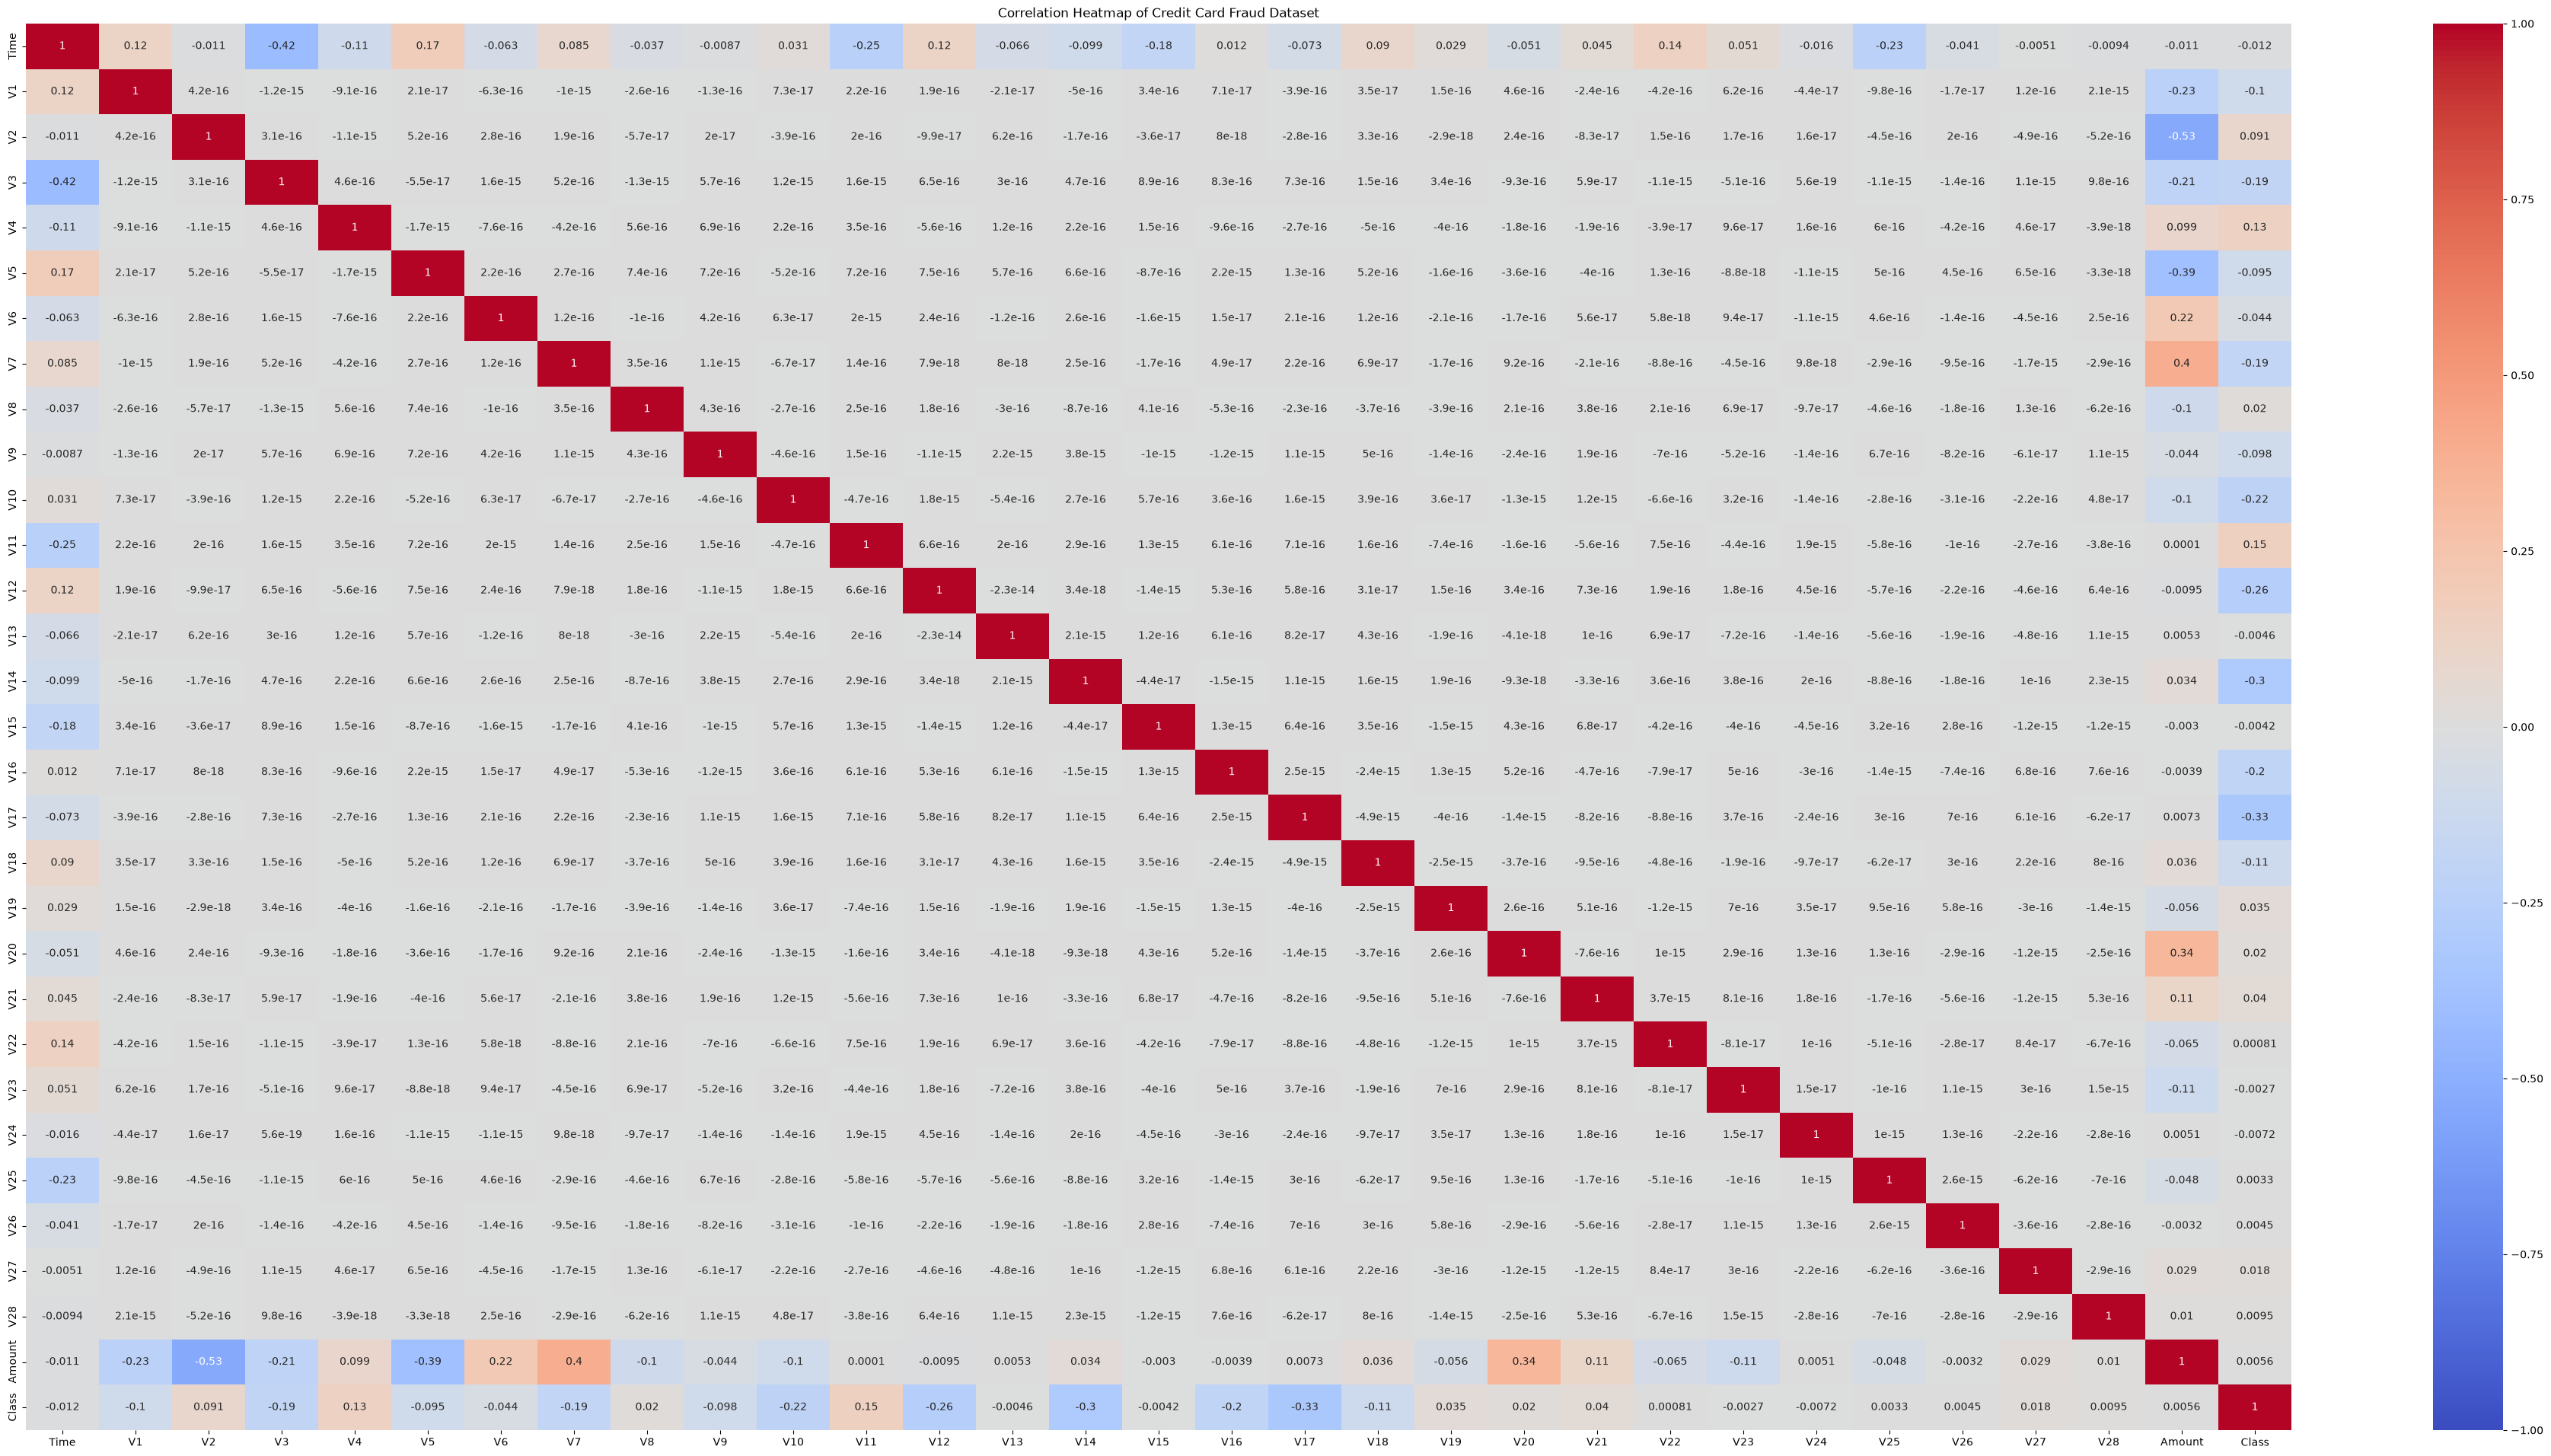

In [13]:
corr = df.corr()
plt.figure(figsize=(48, 24))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Credit Card Fraud Dataset')
plt.show()

In [14]:
most_correlated_features = np.abs(corr['Class']).sort_values(ascending=False)[1:3]
two_most_correlated_features = most_correlated_features.index.tolist()
two_most_correlated_features

['V17', 'V14']

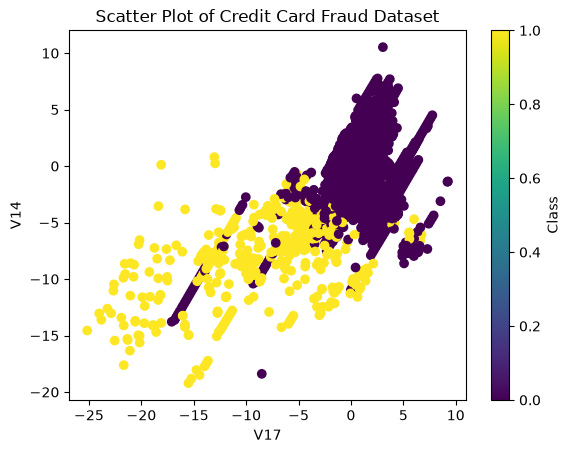

In [15]:
plt.scatter(df[two_most_correlated_features[0]], df[two_most_correlated_features[1]], c=df[target_column], cmap='viridis')
plt.colorbar(label='Class')
plt.xlabel(two_most_correlated_features[0])
plt.ylabel(two_most_correlated_features[1])
plt.title('Scatter Plot of Credit Card Fraud Dataset')
plt.show()

In [16]:
X = df.drop(target_column, axis=1)
y = df[target_column]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


In [20]:

pd.DataFrame(X_train_scaled).to_csv('../_data/X_train_scaled.csv')
pd.DataFrame(X_test_scaled).to_csv('../_data/X_test_scaled.csv')
pd.DataFrame(y_train).to_csv('../_data/y_train.csv')
pd.DataFrame(y_test).to_csv('../_data/y_test.csv')


In [23]:
def save_model(model, model_name):
    joblib.dump(model, f'../_models/{model_name}_{time.strftime("%Y_%m_%d_%H_%M_%S")}.pkl')

def load_model(model_name):
    return joblib.load(f'../_models/{model_name}.pkl')


In [22]:
def generate_evaluation_metrics(model_name, y_train, y_test, y_train_pred, y_test_pred):
    f1_train = f1_score(y_train, y_train_pred)
    f1_test = f1_score(y_test, y_test_pred)
    accuracy_train = accuracy_score(y_train, y_train_pred)
    accuracy_test = accuracy_score(y_test, y_test_pred)
    precision_train = precision_score(y_train, y_train_pred)
    precision_test = precision_score(y_test, y_test_pred)
    recall_train = recall_score(y_train, y_train_pred)
    recall_test = recall_score(y_test, y_test_pred)

    class_labels = ["Legitimate", "Fraud"]
    report_dict = classification_report(
        y_test, y_test_pred, target_names=class_labels, output_dict=True
    )
    # accuracy is a scalar in the report dict, not a per-class metric like the others
    accuracy = report_dict.pop("accuracy")
    report_df = pd.DataFrame(report_dict).T
    report_df["accuracy"] = accuracy
    report_metrics = report_df[["precision", "recall", "f1-score", "support", "accuracy"]]

    cm = confusion_matrix(y_test, y_test_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(
        report_metrics,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        ax=axes[0],
    )
    axes[0].set_title(f"{model_name} Classification Report")
    axes[0].set_ylabel("")

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=axes[1],
    )
    axes[1].set_title(f"{model_name} Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

    return {
        "model_name": model_name,
        "f1_train": f1_train,
        "f1_test": f1_test,
        "accuracy_train": accuracy_train,
        "accuracy_test": accuracy_test,
        "precision_train": precision_train,
        "precision_test": precision_test,
        "recall_train": recall_train,
        "recall_test": recall_test,
    }


In [50]:
dt_baseline_model = DecisionTreeClassifier()
dt_baseline_model.fit(X_train_scaled, y_train)

y_train_pred = dt_baseline_model.predict(X_train_scaled)
y_test_pred = dt_baseline_model.predict(X_test_scaled)

In [74]:
save_model(dt_baseline_model, "dt_baseline_model")

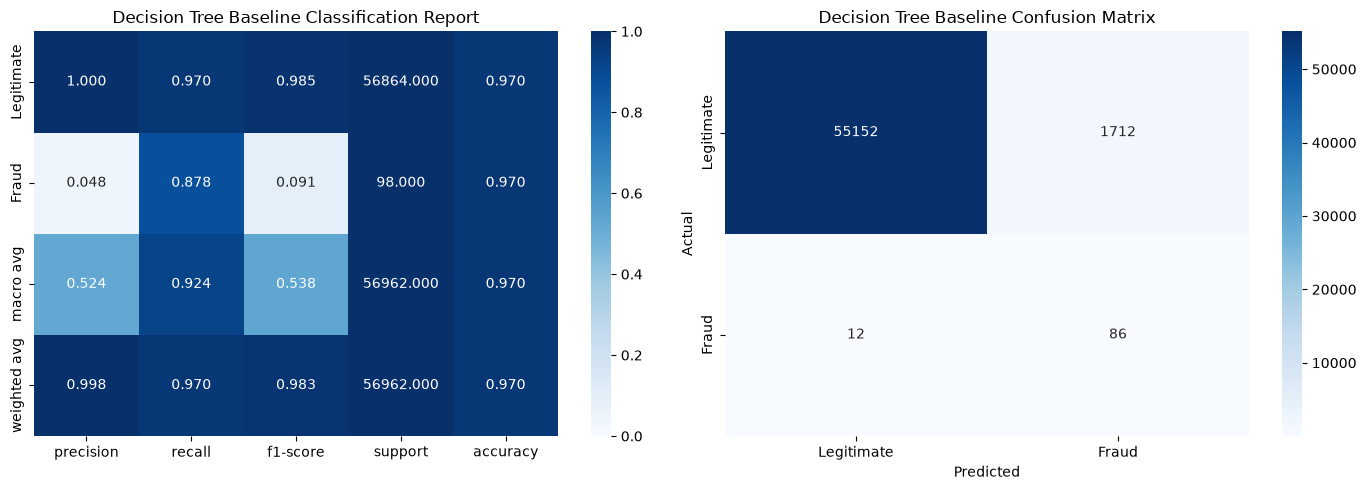

In [73]:
evaluation_metrics = generate_evaluation_metrics("Decision Tree Baseline", y_train, y_test, y_train_pred, y_test_pred)

In [56]:
knn_baseline_model = KNeighborsClassifier()
knn_baseline_model.fit(X_train_scaled, y_train)

y_test_pred = knn_baseline_model.predict(X_test_scaled)
y_train_pred = knn_baseline_model.predict(X_train_scaled)

In [75]:
save_model(knn_baseline_model, "knn_baseline_model")

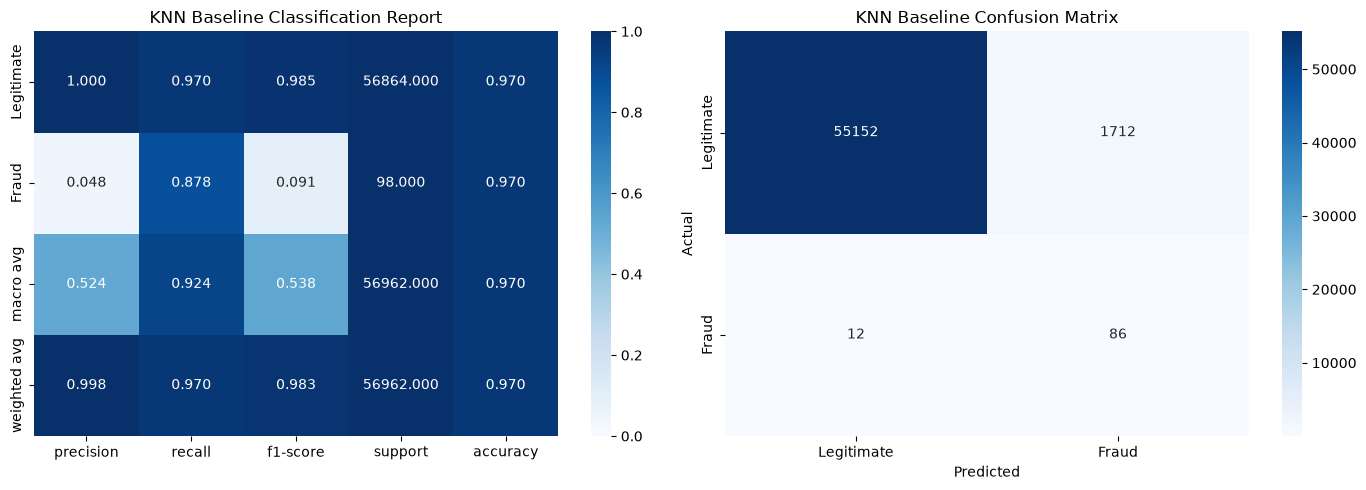

In [70]:
evaluation_metrics = generate_evaluation_metrics("KNN Baseline", y_train, y_test, y_train_pred, y_test_pred)

In [58]:
logistic_baseline_model = LogisticRegression()
logistic_baseline_model.fit(X_train_scaled, y_train)

y_test_pred = logistic_baseline_model.predict(X_test_scaled)
y_train_pred = logistic_baseline_model.predict(X_train_scaled)

In [76]:
save_model(logistic_baseline_model, "logistic_baseline_model")

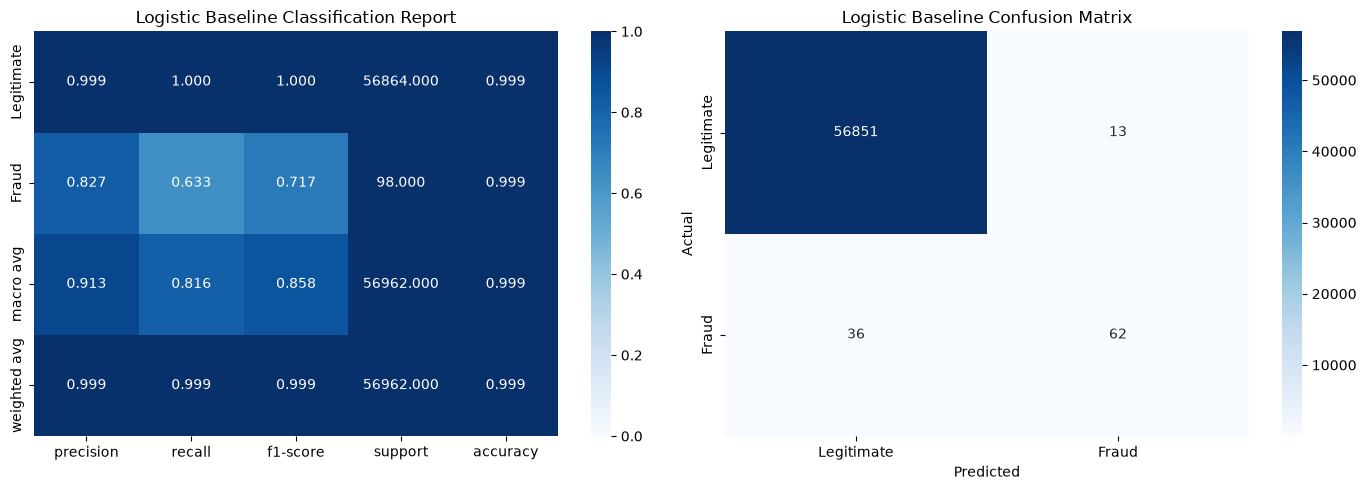

In [59]:
evaluation_metrics = generate_evaluation_metrics("Logistic Baseline", y_train, y_test, y_train_pred, y_test_pred)

In [78]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("dt", DecisionTreeClassifier(random_state=42)),
])

param_distributions = {
    "dt__criterion": ["gini", "entropy"],
    "dt__max_depth": [None, 5, 10, 15, 20, 30, 40, 50, 60],
    "dt__min_samples_split": list(range(2, 101)),
    "dt__min_samples_leaf": list(range(1, 101)),
    "dt__max_features": ["sqrt", "log2", None],
    "dt__class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_random_search_result = RandomizedSearchCV(
    pipe,
    param_distributions,
    n_iter=100,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=3,
)

dt_random_search_result.fit(X_train, y_train)  # unscaled; pipeline scales per fold

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 2/5] END dt__class_weight=balanced, dt__criterion=gini, dt__max_depth=20, dt__max_features=log2, dt__min_samples_leaf=80, dt__min_samples_split=36;, score=0.133 total time=   0.9s
[CV 1/5] END dt__class_weight=balanced, dt__criterion=gini, dt__max_depth=20, dt__max_features=log2, dt__min_samples_leaf=80, dt__min_samples_split=36;, score=0.156 total time=   1.1s
[CV 4/5] END dt__class_weight=balanced, dt__criterion=gini, dt__max_depth=20, dt__max_features=log2, dt__min_samples_leaf=80, dt__min_samples_split=36;, score=0.140 total time=   1.2s
[CV 3/5] END dt__class_weight=balanced, dt__criterion=gini, dt__max_depth=20, dt__max_features=log2, dt__min_samples_leaf=80, dt__min_samples_split=36;, score=0.156 total time=   1.2s
[CV 5/5] END dt__class_weight=balanced, dt__criterion=gini, dt__max_depth=20, dt__max_features=log2, dt__min_samples_leaf=80, dt__min_samples_split=36;, score=0.133 total time=   1.3s
[CV 2/5] END dt__

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'dt__class_weight': [None, 'balanced'], 'dt__criterion': ['gini', 'entropy'], 'dt__max_depth': [None, 5, ...], 'dt__max_features': ['sqrt', 'log2', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best e

Best dt random search Recall params: {'dt__min_samples_split': 54, 'dt__min_samples_leaf': 23, 'dt__max_features': None, 'dt__max_depth': 5, 'dt__criterion': 'entropy', 'dt__class_weight': None}
Best dt random search Recall CV Recall: 0.8079165776787175


/Users/amir/miniconda3/envs/maktab/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/amir/miniconda3/envs/maktab/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


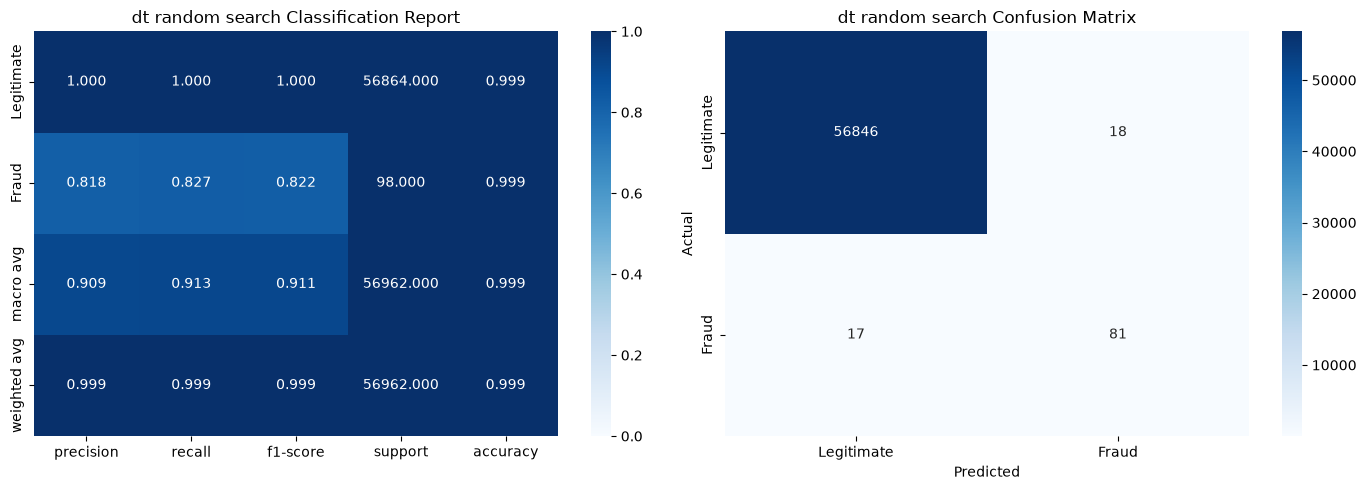

{'model_name': 'dt random search',
 'f1_train': 0.8081081081081081,
 'f1_test': 0.8223350253807107,
 'accuracy_train': 0.9993767692949154,
 'accuracy_test': 0.999385555282469,
 'precision_train': 0.8641618497109826,
 'precision_test': 0.8181818181818182,
 'recall_train': 0.7588832487309645,
 'recall_test': 0.826530612244898}

In [79]:
print("Best dt random search Recall params:", dt_random_search_result.best_params_)
print("Best dt random search Recall CV Recall:", dt_random_search_result.best_score_)

y_test_pred = dt_random_search_result.predict(X_test_scaled)
y_train_pred = dt_random_search_result.predict(X_train_scaled)

generate_evaluation_metrics("dt random search", y_train, y_test, y_train_pred, y_test_pred)

In [80]:
save_model(dt_random_search_result, "dt_random_search_result")

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier()),  # KNN has no random_state
])

knn_param_distributions = {
    "knn__n_neighbors": list(range(1, 51)),
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan", "minkowski"],
    "knn__p": [1, 2],
    "knn__leaf_size": [20, 30, 40, 50],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_random_search_result = RandomizedSearchCV(
    knn_pipe,
    knn_param_distributions,
    n_iter=50,  # KNN is slower than DT; 50 iters x 5 folds is already heavy
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=3,
)

knn_random_search_result.fit(X_train, y_train)  # unscaled; pipeline scales per fold

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 3/5] END knn__leaf_size=50, knn__metric=euclidean, knn__n_neighbors=45, knn__p=2, knn__weights=uniform;, score=0.787 total time=  19.2s
[CV 1/5] END knn__leaf_size=50, knn__metric=euclidean, knn__n_neighbors=45, knn__p=2, knn__weights=uniform;, score=0.824 total time=  19.3s
[CV 4/5] END knn__leaf_size=50, knn__metric=euclidean, knn__n_neighbors=45, knn__p=2, knn__weights=uniform;, score=0.808 total time=  19.5s
[CV 2/5] END knn__leaf_size=50, knn__metric=euclidean, knn__n_neighbors=45, knn__p=2, knn__weights=uniform;, score=0.771 total time=  19.7s
[CV 5/5] END knn__leaf_size=50, knn__metric=euclidean, knn__n_neighbors=45, knn__p=2, knn__weights=uniform;, score=0.779 total time=  19.8s
[CV 1/5] END knn__leaf_size=40, knn__metric=minkowski, knn__n_neighbors=30, knn__p=2, knn__weights=distance;, score=0.830 total time=  19.6s
[CV 2/5] END knn__leaf_size=40, knn__metric=minkowski, knn__n_neighbors=30, knn__p=2, knn__weight

/Users/amir/miniconda3/envs/maktab/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV 1/5] END knn__leaf_size=40, knn__metric=minkowski, knn__n_neighbors=28, knn__p=2, knn__weights=distance;, score=0.830 total time=  20.3s
[CV 4/5] END knn__leaf_size=40, knn__metric=euclidean, knn__n_neighbors=44, knn__p=2, knn__weights=distance;, score=0.821 total time=  21.1s
[CV 5/5] END knn__leaf_size=40, knn__metric=euclidean, knn__n_neighbors=44, knn__p=2, knn__weights=distance;, score=0.816 total time=  21.0s
[CV 1/5] END knn__leaf_size=50, knn__metric=manhattan, knn__n_neighbors=5, knn__p=2, knn__weights=distance;, score=0.833 total time= 1.4min
[CV 2/5] END knn__leaf_size=40, knn__metric=minkowski, knn__n_neighbors=28, knn__p=2, knn__weights=distance;, score=0.791 total time=  20.3s
[CV 3/5] END knn__leaf_size=40, knn__metric=minkowski, knn__n_neighbors=28, knn__p=2, knn__weights=distance;, score=0.822 total time=  19.7s
[CV 2/5] END knn__leaf_size=40, knn__metric=euclidean, knn__n_neighbors=23, knn__p=1, knn__weights=distance;, score=0.800 total time=  19.8s
[CV 1/5] END k

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'knn__leaf_size': [20, 30, ...], 'knn__metric': ['euclidean', 'manhattan', ...], 'knn__n_neighbors': [1, 2, ...], 'knn__p': [1, 2], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can

Best knn random search params: {'knn__weights': 'uniform', 'knn__p': 2, 'knn__n_neighbors': 3, 'knn__metric': 'minkowski', 'knn__leaf_size': 30}
Best knn random search CV F1: 0.8506560844440754


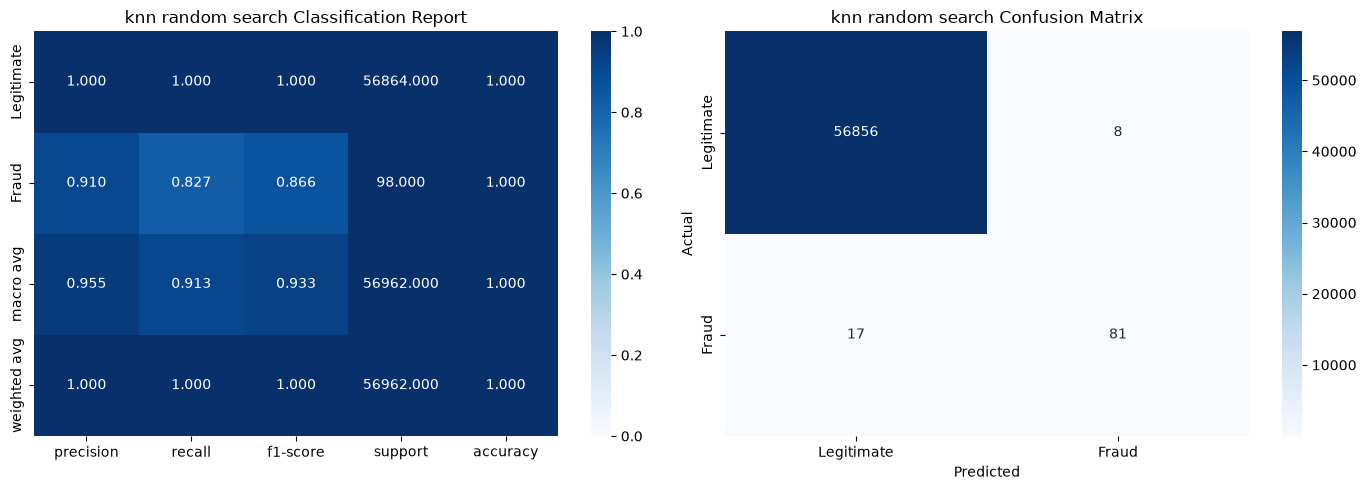

{'model_name': 'knn random search',
 'f1_train': 0.883008356545961,
 'f1_test': 0.8663101604278075,
 'accuracy_train': 0.9996313283153021,
 'accuracy_test': 0.9995611109160493,
 'precision_train': 0.9783950617283951,
 'precision_test': 0.9101123595505618,
 'recall_train': 0.8045685279187818,
 'recall_test': 0.826530612244898}

In [25]:
print("Best knn random search params:", knn_random_search_result.best_params_)
print("Best knn random search CV F1:", knn_random_search_result.best_score_)

y_test_pred = knn_random_search_result.predict(X_test)
y_train_pred = knn_random_search_result.predict(X_train)

generate_evaluation_metrics("knn random search", y_train, y_test, y_train_pred, y_test_pred)

In [26]:
save_model(knn_random_search_result, "knn_random_search_result")

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

rf_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(random_state=42)),
])

rf_param_distributions = {
    "rf__n_estimators": [50, 100, 200, 300, 500],
    "rf__criterion": ["gini", "entropy"],
    "rf__max_depth": [None, 5, 10, 15, 20, 30, 40, 50],
    "rf__min_samples_split": list(range(2, 101)),
    "rf__min_samples_leaf": list(range(1, 101)),
    "rf__max_features": ["sqrt", "log2", None],
    "rf__class_weight": [None, "balanced", "balanced_subsample"],
    "rf__bootstrap": [True, False],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_random_search_result = RandomizedSearchCV(
    rf_pipe,
    rf_param_distributions,
    n_iter=50,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=3,
)

rf_random_search_result.fit(X_train, y_train)  # unscaled; pipeline scales per fold

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 5/5] END rf__bootstrap=True, rf__class_weight=balanced_subsample, rf__criterion=entropy, rf__max_depth=15, rf__max_features=sqrt, rf__min_samples_leaf=77, rf__min_samples_split=55, rf__n_estimators=300;, score=0.784 total time= 2.2min
[CV 2/5] END rf__bootstrap=True, rf__class_weight=balanced_subsample, rf__criterion=entropy, rf__max_depth=15, rf__max_features=sqrt, rf__min_samples_leaf=77, rf__min_samples_split=55, rf__n_estimators=300;, score=0.753 total time= 2.2min
[CV 1/5] END rf__bootstrap=True, rf__class_weight=balanced_subsample, rf__criterion=entropy, rf__max_depth=15, rf__max_features=sqrt, rf__min_samples_leaf=77, rf__min_samples_split=55, rf__n_estimators=300;, score=0.775 total time= 2.3min
[CV 4/5] END rf__bootstrap=True, rf__class_weight=balanced_subsample, rf__criterion=entropy, rf__max_depth=15, rf__max_features=sqrt, rf__min_samples_leaf=77, rf__min_samples_split=55, rf__n_estimators=300;, score=0.774 t

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'rf__bootstrap': [True, False], 'rf__class_weight': [None, 'balanced', ...], 'rf__criterion': ['gini', 'entropy'], 'rf__max_depth': [None, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimato

Best rf random search params: {'rf__n_estimators': 100, 'rf__min_samples_split': 17, 'rf__min_samples_leaf': 3, 'rf__max_features': None, 'rf__max_depth': 40, 'rf__criterion': 'gini', 'rf__class_weight': 'balanced_subsample', 'rf__bootstrap': True}
Best rf random search CV F1: 0.8263150434553774


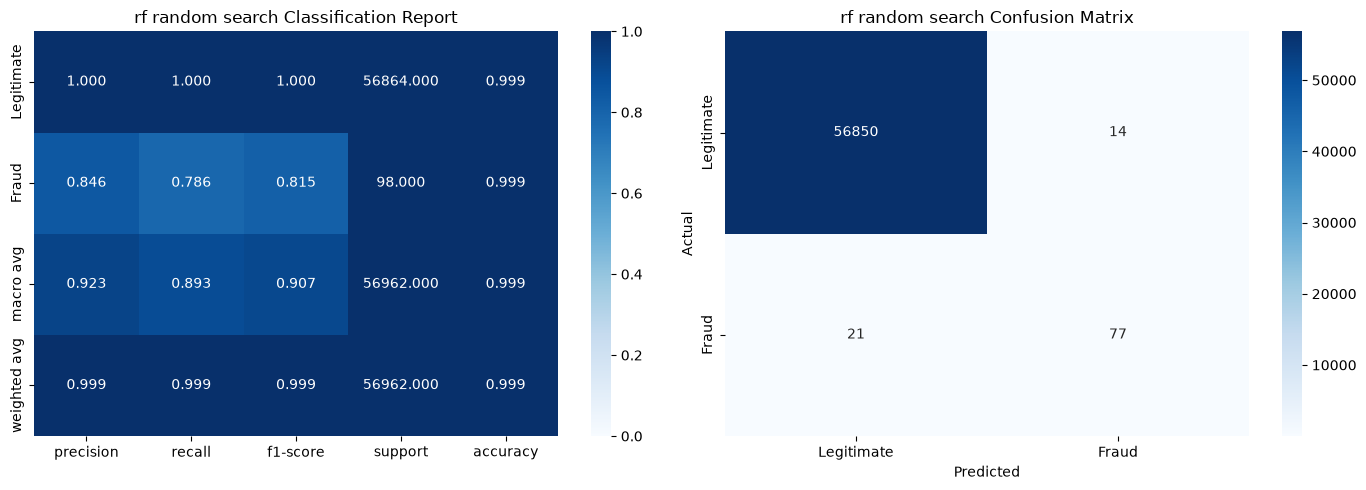

{'model_name': 'rf random search',
 'f1_train': 0.9680589680589681,
 'f1_test': 0.8148148148148148,
 'accuracy_train': 0.9998858873356887,
 'accuracy_test': 0.999385555282469,
 'precision_train': 0.9380952380952381,
 'precision_test': 0.8461538461538461,
 'recall_train': 1.0,
 'recall_test': 0.7857142857142857}

In [28]:
print("Best rf random search params:", rf_random_search_result.best_params_)
print("Best rf random search CV F1:", rf_random_search_result.best_score_)

y_test_pred = rf_random_search_result.predict(X_test)
y_train_pred = rf_random_search_result.predict(X_train)

generate_evaluation_metrics("rf random search", y_train, y_test, y_train_pred, y_test_pred)

In [29]:
save_model(rf_random_search_result, "rf_random_search_result")